In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

from xgboost import XGBClassifier

In [3]:
data = load_breast_cancer()

X= data.data
y= data.target

In [4]:
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [5]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [6]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [7]:
print(data.target_names)
print(data.feature_names)

['malignant' 'benign']
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [9]:
print(pd.Series(y).value_counts())

1    357
0    212
Name: count, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [12]:
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [13]:
y_pred = model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9473684210526315


In [15]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[38  4]
 [ 2 70]]


                 Actual

              0       1

Predicted 0   TN      FN

Predicted 1   FP      TP


TN = 38

FN = 4

FP = 2

TP = 70

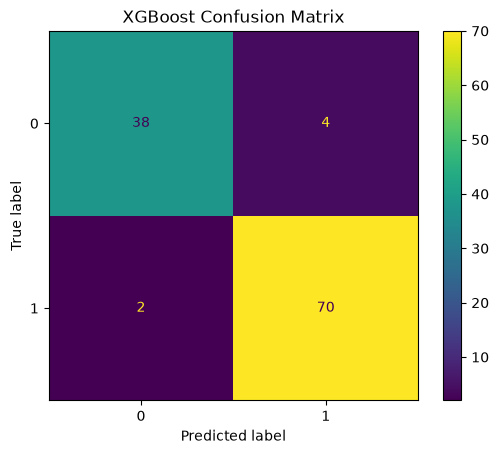

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



Precision


When the model predicts positive, how often is it correct?

In [ ]:
precision_score(y_test, y_pred)

Recall


Out of all actual positive cases, how many did the model detect?

In [19]:
recall_score(y_test, y_pred)

0.9722222222222222

F1


Combines precision and recall.

In [18]:
f1_score(y_test, y_pred)

0.958904109589041

Predict Probability

In [20]:
y_prob = model.predict_proba(X_test)

In [21]:
y_prob

array([[9.9855977e-01, 1.4402528e-03],
       [2.1051764e-03, 9.9789482e-01],
       [9.9105382e-01, 8.9461701e-03],
       [7.8520828e-01, 2.1479172e-01],
       [9.9882489e-01, 1.1751133e-03],
       [3.7765503e-03, 9.9622345e-01],
       [7.3510408e-04, 9.9926490e-01],
       [9.9841070e-01, 1.5892886e-03],
       [9.9891424e-01, 1.0857576e-03],
       [9.9885744e-01, 1.1425627e-03],
       [1.8982291e-03, 9.9810177e-01],
       [9.9769360e-01, 2.3064262e-03],
       [1.8278360e-03, 9.9817216e-01],
       [9.9852157e-01, 1.4784335e-03],
       [9.9778771e-01, 2.2122955e-03],
       [6.2747359e-02, 9.3725264e-01],
       [4.2511320e-01, 5.7488680e-01],
       [2.3212194e-02, 9.7678781e-01],
       [4.6333075e-03, 9.9536669e-01],
       [1.4542520e-02, 9.8545748e-01],
       [9.9834871e-01, 1.6512838e-03],
       [8.6067355e-01, 1.3932647e-01],
       [1.4564991e-03, 9.9854350e-01],
       [1.7023683e-03, 9.9829763e-01],
       [3.9464235e-03, 9.9605358e-01],
       [3.0309486e-01, 6.

Probability of Class 1



In [23]:
y_prob1 = model.predict_proba(X_test)[:, 1]
y_prob1

array([1.4402528e-03, 9.9789482e-01, 8.9461701e-03, 2.1479172e-01,
       1.1751133e-03, 9.9622345e-01, 9.9926490e-01, 1.5892886e-03,
       1.0857576e-03, 1.1425627e-03, 9.9810177e-01, 2.3064262e-03,
       9.9817216e-01, 1.4784335e-03, 2.2122955e-03, 9.3725264e-01,
       5.7488680e-01, 9.7678781e-01, 9.9536669e-01, 9.8545748e-01,
       1.6512838e-03, 1.3932647e-01, 9.9854350e-01, 9.9829763e-01,
       9.9605358e-01, 6.9690514e-01, 8.4556604e-04, 9.9676943e-01,
       9.9919659e-01, 9.9545300e-01, 9.9055380e-01, 9.9911052e-01,
       9.9842107e-01, 9.6657348e-01, 1.0213018e-03, 7.7590871e-01,
       9.9627966e-01, 9.0912014e-01, 8.3795959e-01, 1.2270386e-03,
       9.9903959e-01, 9.9853790e-01, 9.9740332e-01, 1.1425627e-03,
       1.4995356e-03, 9.2143035e-01, 9.9774075e-01, 9.9913651e-01,
       8.2014525e-01, 9.8778016e-04, 9.9829215e-01, 8.4339559e-01,
       9.9913824e-01, 8.3056831e-01, 9.7891778e-01, 9.9912959e-01,
       9.9752480e-01, 3.8498773e-03, 1.3989786e-03, 9.9478912e

ROC-AUC

In [24]:
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9933862433862434


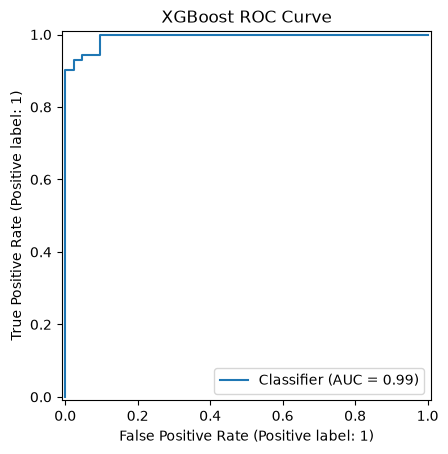

In [25]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("XGBoost ROC Curve")
plt.show()